In [1]:
import os

os.chdir('/home/jwdase/projects/language-detection/src')

In [2]:
from glob import glob

import torch
import matplotlib.pyplot as plt

In [3]:
files = '/om2/user/jwdase/prosody/prosody_only_spect/en/spect/train'

tensor = glob(f'{files}/*')[0]

files = torch.load(tensor, weights_only=True)

In [4]:
spec1, length1 = files['spec'][0], files['length'][0]
spec2, length2 = files['spec'][1], files['length'][1]
spec3, length3 = files['spec'][2], files['length'][2]
spec4, length4 = files['spec'][3], files['length'][3]

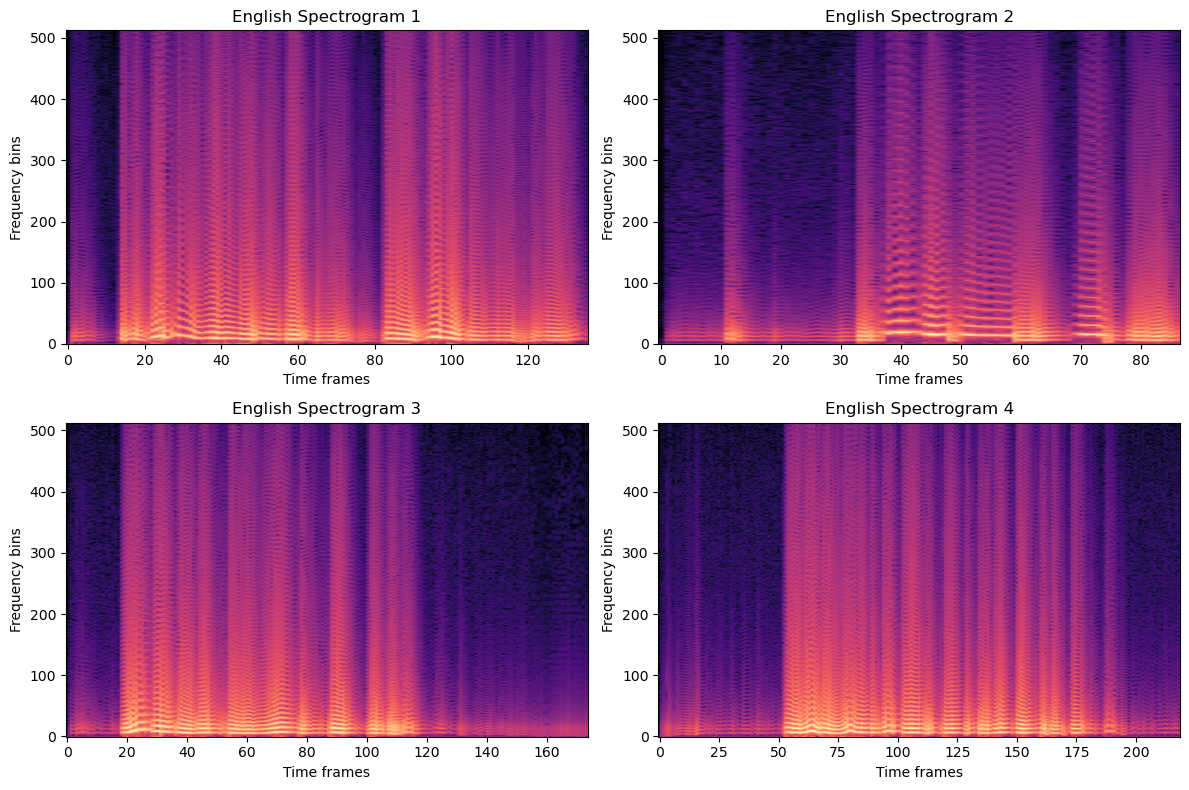

In [5]:
# store in a list for easy iteration
specs = [(spec1, length1),
         (spec2, length2),
         (spec3, length3),
         (spec4, length4)]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, (spec, length) in enumerate(specs):
    # Convert to numpy if it’s a torch tensor
    arr = spec.cpu().numpy() if hasattr(spec, 'cpu') else spec
    # If your spectrogram is [freq, time] make sure you pass it directly
    axes[i].imshow(arr[:, :length], origin='lower', aspect='auto', cmap='magma')
    axes[i].set_title(f"English Spectrogram {i+1}")
    axes[i].set_xlabel("Time frames")
    axes[i].set_ylabel("Frequency bins")

plt.tight_layout()
plt.show()